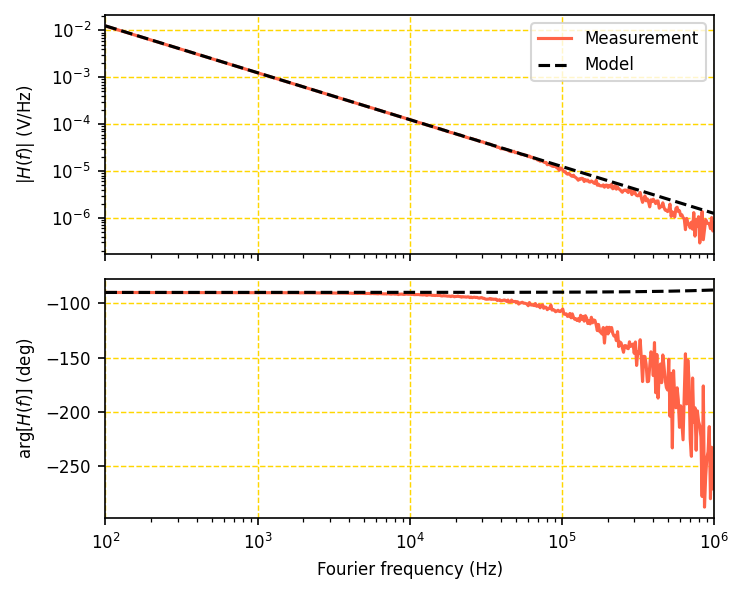

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from loopkit.plots import default_rc
from loopkit import components as lc
from loopkit.component import Component
from loopkit.loop import LOOP 
plt.rcParams.update(default_rc)

# Moku:Pro Lock-In Amplifier measurement:
# Frequency (Hz), Magnitude (dB), Phase (deg)
input_tf = """
9.99999994e+01, -3.8127e+01, -9.0018e+01
1.01818756e+02, -3.8282e+01, -9.0019e+01
1.03670591e+02, -3.8438e+01, -9.0019e+01
1.05556107e+02, -3.8593e+01, -9.0019e+01
1.07475915e+02, -3.8749e+01, -9.0019e+01
1.09430640e+02, -3.8904e+01, -9.0019e+01
1.11420917e+02, -3.9060e+01, -9.0020e+01
1.13447392e+02, -3.9216e+01, -9.0021e+01
1.15510724e+02, -3.9372e+01, -9.0021e+01
1.17611583e+02, -3.9527e+01, -9.0021e+01
1.19750651e+02, -3.9683e+01, -9.0021e+01
1.21928624e+02, -3.9839e+01, -9.0022e+01
1.24146209e+02, -3.9995e+01, -9.0022e+01
1.26404126e+02, -4.0150e+01, -9.0022e+01
1.28703109e+02, -4.0306e+01, -9.0023e+01
1.31043905e+02, -4.0462e+01, -9.0023e+01
1.33427275e+02, -4.0618e+01, -9.0024e+01
1.35853992e+02, -4.0774e+01, -9.0025e+01
1.38324845e+02, -4.0930e+01, -9.0025e+01
1.40840637e+02, -4.1086e+01, -9.0026e+01
1.43402186e+02, -4.1242e+01, -9.0026e+01
1.46010322e+02, -4.1398e+01, -9.0027e+01
1.48665894e+02, -4.1554e+01, -9.0026e+01
1.51369765e+02, -4.1710e+01, -9.0028e+01
1.54122812e+02, -4.1865e+01, -9.0028e+01
1.56925931e+02, -4.2022e+01, -9.0028e+01
1.59780032e+02, -4.2178e+01, -9.0030e+01
1.62686041e+02, -4.2334e+01, -9.0030e+01
1.65644904e+02, -4.2489e+01, -9.0030e+01
1.68657582e+02, -4.2646e+01, -9.0031e+01
1.71725052e+02, -4.2802e+01, -9.0031e+01
1.74848313e+02, -4.2958e+01, -9.0031e+01
1.78028378e+02, -4.3114e+01, -9.0031e+01
1.81266280e+02, -4.3270e+01, -9.0033e+01
1.84563073e+02, -4.3426e+01, -9.0034e+01
1.87919826e+02, -4.3582e+01, -9.0033e+01
1.91337630e+02, -4.3738e+01, -9.0034e+01
1.94817595e+02, -4.3894e+01, -9.0036e+01
1.98360853e+02, -4.4051e+01, -9.0035e+01
2.01968554e+02, -4.4207e+01, -9.0035e+01
2.05641870e+02, -4.4363e+01, -9.0037e+01
2.09381995e+02, -4.4519e+01, -9.0038e+01
2.13190143e+02, -4.4675e+01, -9.0038e+01
2.17067553e+02, -4.4831e+01, -9.0039e+01
2.21015483e+02, -4.4987e+01, -9.0040e+01
2.25035216e+02, -4.5144e+01, -9.0041e+01
2.29128059e+02, -4.5300e+01, -9.0041e+01
2.33295340e+02, -4.5456e+01, -9.0042e+01
2.37538414e+02, -4.5613e+01, -9.0043e+01
2.41858660e+02, -4.5769e+01, -9.0043e+01
2.46257480e+02, -4.5925e+01, -9.0042e+01
2.50736304e+02, -4.6081e+01, -9.0044e+01
2.55296586e+02, -4.6237e+01, -9.0046e+01
2.59939810e+02, -4.6394e+01, -9.0048e+01
2.64667482e+02, -4.6550e+01, -9.0050e+01
2.69481139e+02, -4.6706e+01, -9.0049e+01
2.74382344e+02, -4.6862e+01, -9.0050e+01
2.79372691e+02, -4.7019e+01, -9.0051e+01
2.84453800e+02, -4.7175e+01, -9.0051e+01
2.89627322e+02, -4.7332e+01, -9.0052e+01
2.94894938e+02, -4.7488e+01, -9.0054e+01
3.00258358e+02, -4.7645e+01, -9.0054e+01
3.05719327e+02, -4.7801e+01, -9.0056e+01
3.11279617e+02, -4.7957e+01, -9.0056e+01
3.16941035e+02, -4.8114e+01, -9.0057e+01
3.22705421e+02, -4.8269e+01, -9.0059e+01
3.28574646e+02, -4.8426e+01, -9.0059e+01
3.34550619e+02, -4.8583e+01, -9.0062e+01
3.40635280e+02, -4.8739e+01, -9.0062e+01
3.46830606e+02, -4.8895e+01, -9.0062e+01
3.53138610e+02, -4.9051e+01, -9.0061e+01
3.59561342e+02, -4.9207e+01, -9.0066e+01
3.66100887e+02, -4.9364e+01, -9.0068e+01
3.72759371e+02, -4.9521e+01, -9.0069e+01
3.79538956e+02, -4.9677e+01, -9.0070e+01
3.86441845e+02, -4.9833e+01, -9.0070e+01
3.93470281e+02, -4.9990e+01, -9.0069e+01
4.00626547e+02, -5.0145e+01, -9.0073e+01
4.07912969e+02, -5.0302e+01, -9.0073e+01
4.15331912e+02, -5.0459e+01, -9.0073e+01
4.22885788e+02, -5.0615e+01, -9.0077e+01
4.30577051e+02, -5.0772e+01, -9.0075e+01
4.38408199e+02, -5.0927e+01, -9.0079e+01
4.46381777e+02, -5.1085e+01, -9.0081e+01
4.54500374e+02, -5.1241e+01, -9.0081e+01
4.62766629e+02, -5.1398e+01, -9.0083e+01
4.71183227e+02, -5.1554e+01, -9.0088e+01
4.79752903e+02, -5.1710e+01, -9.0088e+01
4.88478440e+02, -5.1866e+01, -9.0091e+01
4.97362673e+02, -5.2024e+01, -9.0092e+01
5.06408489e+02, -5.2179e+01, -9.0093e+01
5.15618826e+02, -5.2335e+01, -9.0095e+01
5.24996677e+02, -5.2492e+01, -9.0102e+01
5.34545088e+02, -5.2648e+01, -9.0096e+01
5.44267161e+02, -5.2805e+01, -9.0099e+01
5.54166055e+02, -5.2961e+01, -9.0096e+01
5.64244987e+02, -5.3117e+01, -9.0101e+01
5.74507229e+02, -5.3274e+01, -9.0106e+01
5.84956116e+02, -5.3431e+01, -9.0106e+01
5.95595043e+02, -5.3586e+01, -9.0107e+01
6.06427467e+02, -5.3743e+01, -9.0113e+01
6.17456906e+02, -5.3899e+01, -9.0113e+01
6.28686943e+02, -5.4056e+01, -9.0115e+01
6.40121228e+02, -5.4214e+01, -9.0116e+01
6.51763474e+02, -5.4369e+01, -9.0108e+01
6.63617465e+02, -5.4526e+01, -9.0119e+01
6.75687050e+02, -5.4682e+01, -9.0131e+01
6.87976152e+02, -5.4838e+01, -9.0123e+01
7.00488763e+02, -5.4993e+01, -9.0132e+01
7.13228948e+02, -5.5151e+01, -9.0128e+01
7.26200845e+02, -5.5306e+01, -9.0132e+01
7.39408670e+02, -5.5465e+01, -9.0137e+01
7.52856713e+02, -5.5620e+01, -9.0136e+01
7.66549344e+02, -5.5778e+01, -9.0147e+01
7.80491010e+02, -5.5934e+01, -9.0155e+01
7.94686240e+02, -5.6092e+01, -9.0141e+01
8.09139648e+02, -5.6247e+01, -9.0140e+01
8.23855928e+02, -5.6405e+01, -9.0146e+01
8.38839861e+02, -5.6559e+01, -9.0147e+01
8.54096315e+02, -5.6716e+01, -9.0153e+01
8.69630247e+02, -5.6873e+01, -9.0152e+01
8.85446704e+02, -5.7029e+01, -9.0178e+01
9.01550823e+02, -5.7186e+01, -9.0159e+01
9.17947837e+02, -5.7343e+01, -9.0173e+01
9.34643073e+02, -5.7497e+01, -9.0172e+01
9.51641954e+02, -5.7657e+01, -9.0173e+01
9.68950004e+02, -5.7810e+01, -9.0178e+01
9.86572845e+02, -5.7967e+01, -9.0178e+01
1.00451620e+03, -5.8125e+01, -9.0189e+01
1.02278591e+03, -5.8281e+01, -9.0177e+01
1.04138789e+03, -5.8439e+01, -9.0194e+01
1.06032820e+03, -5.8593e+01, -9.0199e+01
1.07961299e+03, -5.8751e+01, -9.0211e+01
1.09924852e+03, -5.8906e+01, -9.0202e+01
1.11924117e+03, -5.9062e+01, -9.0199e+01
1.13959744e+03, -5.9215e+01, -9.0214e+01
1.16032395e+03, -5.9376e+01, -9.0203e+01
1.18142741e+03, -5.9531e+01, -9.0225e+01
1.20291470e+03, -5.9684e+01, -9.0207e+01
1.22479279e+03, -5.9845e+01, -9.0217e+01
1.24706879e+03, -5.9999e+01, -9.0225e+01
1.26974993e+03, -6.0159e+01, -9.0234e+01
1.29284359e+03, -6.0312e+01, -9.0235e+01
1.31635727e+03, -6.0467e+01, -9.0248e+01
1.34029860e+03, -6.0624e+01, -9.0242e+01
1.36467537e+03, -6.0774e+01, -9.0251e+01
1.38949549e+03, -6.0936e+01, -9.0252e+01
1.41476703e+03, -6.1093e+01, -9.0262e+01
1.44049820e+03, -6.1253e+01, -9.0234e+01
1.46669735e+03, -6.1411e+01, -9.0260e+01
1.49337301e+03, -6.1566e+01, -9.0256e+01
1.52053382e+03, -6.1726e+01, -9.0274e+01
1.54818863e+03, -6.1881e+01, -9.0295e+01
1.57634641e+03, -6.2033e+01, -9.0296e+01
1.60501631e+03, -6.2193e+01, -9.0279e+01
1.63420765e+03, -6.2345e+01, -9.0296e+01
1.66392991e+03, -6.2502e+01, -9.0297e+01
1.69419274e+03, -6.2653e+01, -9.0274e+01
1.72500598e+03, -6.2813e+01, -9.0314e+01
1.75637964e+03, -6.2985e+01, -9.0299e+01
1.78832391e+03, -6.3127e+01, -9.0331e+01
1.82084917e+03, -6.3289e+01, -9.0329e+01
1.85396598e+03, -6.3440e+01, -9.0347e+01
1.88768511e+03, -6.3592e+01, -9.0360e+01
1.92201750e+03, -6.3755e+01, -9.0385e+01
1.95697432e+03, -6.3907e+01, -9.0320e+01
1.99256692e+03, -6.4069e+01, -9.0364e+01
2.02880686e+03, -6.4232e+01, -9.0360e+01
2.06570591e+03, -6.4386e+01, -9.0398e+01
2.10327607e+03, -6.4532e+01, -9.0339e+01
2.14152954e+03, -6.4701e+01, -9.0410e+01
2.18047875e+03, -6.4844e+01, -9.0383e+01
2.22013635e+03, -6.5006e+01, -9.0429e+01
2.26051522e+03, -6.5155e+01, -9.0376e+01
2.30162849e+03, -6.5319e+01, -9.0397e+01
2.34348951e+03, -6.5466e+01, -9.0443e+01
2.38611187e+03, -6.5637e+01, -9.0414e+01
2.42950944e+03, -6.5793e+01, -9.0384e+01
2.47369630e+03, -6.5950e+01, -9.0430e+01
2.51868681e+03, -6.6093e+01, -9.0463e+01
2.56449559e+03, -6.6251e+01, -9.0472e+01
2.61113752e+03, -6.6407e+01, -9.0469e+01
2.65862775e+03, -6.6561e+01, -9.0494e+01
2.70698172e+03, -6.6719e+01, -9.0496e+01
2.75621512e+03, -6.6882e+01, -9.0494e+01
2.80634396e+03, -6.7049e+01, -9.0487e+01
2.85738453e+03, -6.7182e+01, -9.0477e+01
2.90935339e+03, -6.7359e+01, -9.0498e+01
2.96226745e+03, -6.7508e+01, -9.0561e+01
3.01614388e+03, -6.7658e+01, -9.0528e+01
3.07100019e+03, -6.7822e+01, -9.0601e+01
3.12685420e+03, -6.7974e+01, -9.0607e+01
3.18372407e+03, -6.8131e+01, -9.0530e+01
3.24162826e+03, -6.8298e+01, -9.0610e+01
3.30058558e+03, -6.8453e+01, -9.0571e+01
3.36061519e+03, -6.8606e+01, -9.0598e+01
3.42173660e+03, -6.8751e+01, -9.0580e+01
3.48396966e+03, -6.8911e+01, -9.0568e+01
3.54733458e+03, -6.9062e+01, -9.0642e+01
3.61185196e+03, -6.9234e+01, -9.0617e+01
3.67754275e+03, -6.9375e+01, -9.0624e+01
3.74442830e+03, -6.9537e+01, -9.0616e+01
3.81253033e+03, -6.9686e+01, -9.0708e+01
3.88187097e+03, -6.9864e+01, -9.0706e+01
3.95247275e+03, -7.0042e+01, -9.0736e+01
4.02435860e+03, -7.0158e+01, -9.0652e+01
4.09755189e+03, -7.0323e+01, -9.0653e+01
4.17207638e+03, -7.0474e+01, -9.0785e+01
4.24795629e+03, -7.0642e+01, -9.0768e+01
4.32521627e+03, -7.0784e+01, -9.0861e+01
4.40388142e+03, -7.0952e+01, -9.0787e+01
4.48397730e+03, -7.1131e+01, -9.0817e+01
4.56552992e+03, -7.1239e+01, -9.0887e+01
4.64856580e+03, -7.1407e+01, -9.0752e+01
4.73311189e+03, -7.1591e+01, -9.0826e+01
4.81919567e+03, -7.1747e+01, -9.0786e+01
4.90684510e+03, -7.1875e+01, -9.0859e+01
4.99608866e+03, -7.2046e+01, -9.0866e+01
5.08695535e+03, -7.2182e+01, -9.0979e+01
5.17947468e+03, -7.2350e+01, -9.0947e+01
5.27367671e+03, -7.2513e+01, -9.0949e+01
5.36959205e+03, -7.2649e+01, -9.0906e+01
5.46725185e+03, -7.2847e+01, -9.0965e+01
5.56668785e+03, -7.2963e+01, -9.1097e+01
5.66793235e+03, -7.3114e+01, -9.0908e+01
5.77101823e+03, -7.3288e+01, -9.1061e+01
5.87597900e+03, -7.3460e+01, -9.1050e+01
5.98284875e+03, -7.3634e+01, -9.1101e+01
6.09166220e+03, -7.3762e+01, -9.1157e+01
6.20245470e+03, -7.3899e+01, -9.1273e+01
6.31526225e+03, -7.4064e+01, -9.1034e+01
6.43012149e+03, -7.4218e+01, -9.1108e+01
6.54706974e+03, -7.4346e+01, -9.1183e+01
6.66614499e+03, -7.4593e+01, -9.1311e+01
6.78738594e+03, -7.4703e+01, -9.1347e+01
6.91083196e+03, -7.4849e+01, -9.1269e+01
7.03652316e+03, -7.5013e+01, -9.1439e+01
7.16450038e+03, -7.5165e+01, -9.1181e+01
7.29480520e+03, -7.5305e+01, -9.1281e+01
7.42747994e+03, -7.5477e+01, -9.1451e+01
7.56256771e+03, -7.5643e+01, -9.1557e+01
7.70011240e+03, -7.5784e+01, -9.1376e+01
7.84015870e+03, -7.5911e+01, -9.1381e+01
7.98275209e+03, -7.6103e+01, -9.1533e+01
8.12793891e+03, -7.6263e+01, -9.1521e+01
8.27576633e+03, -7.6452e+01, -9.1476e+01
8.42628236e+03, -7.6586e+01, -9.1956e+01
8.57953592e+03, -7.6749e+01, -9.1535e+01
8.73557679e+03, -7.6858e+01, -9.1593e+01
8.89445566e+03, -7.7030e+01, -9.1496e+01
9.05622414e+03, -7.7194e+01, -9.1763e+01
9.22093481e+03, -7.7374e+01, -9.1767e+01
9.38864116e+03, -7.7487e+01, -9.1630e+01
9.55939768e+03, -7.7680e+01, -9.1438e+01
9.73325984e+03, -7.7880e+01, -9.1670e+01
9.91028413e+03, -7.8016e+01, -9.1667e+01
1.00905281e+04, -7.8161e+01, -9.1638e+01
1.02740502e+04, -7.8294e+01, -9.1824e+01
1.04609102e+04, -7.8415e+01, -9.1559e+01
1.06511686e+04, -7.8640e+01, -9.1982e+01
1.08448875e+04, -7.8800e+01, -9.1968e+01
1.10421296e+04, -7.8966e+01, -9.1924e+01
1.12429590e+04, -7.9110e+01, -9.1912e+01
1.14474410e+04, -7.9267e+01, -9.1914e+01
1.16556421e+04, -7.9435e+01, -9.2143e+01
1.18676299e+04, -7.9539e+01, -9.2119e+01
1.20834732e+04, -7.9730e+01, -9.2280e+01
1.23032421e+04, -7.9861e+01, -9.2266e+01
1.25270081e+04, -7.9972e+01, -9.2059e+01
1.27548439e+04, -8.0209e+01, -9.2444e+01
1.29868234e+04, -8.0384e+01, -9.2666e+01
1.32230221e+04, -8.0537e+01, -9.2221e+01
1.34635167e+04, -8.0678e+01, -9.2288e+01
1.37083853e+04, -8.0749e+01, -9.2281e+01
1.39577074e+04, -8.0973e+01, -9.2640e+01
1.42115641e+04, -8.1071e+01, -9.2629e+01
1.44700379e+04, -8.1296e+01, -9.2711e+01
1.47332126e+04, -8.1488e+01, -9.2803e+01
1.50011739e+04, -8.1602e+01, -9.2659e+01
1.52740087e+04, -8.1780e+01, -9.2780e+01
1.55518057e+04, -8.1984e+01, -9.2661e+01
1.58346552e+04, -8.1991e+01, -9.2773e+01
1.61226490e+04, -8.2154e+01, -9.3196e+01
1.64158808e+04, -8.2472e+01, -9.3204e+01
1.67144457e+04, -8.2481e+01, -9.2967e+01
1.70184407e+04, -8.2712e+01, -9.3149e+01
1.73279647e+04, -8.2878e+01, -9.3171e+01
1.76431182e+04, -8.3150e+01, -9.3410e+01
1.79640035e+04, -8.3193e+01, -9.3416e+01
1.82907250e+04, -8.3378e+01, -9.3422e+01
1.86233888e+04, -8.3607e+01, -9.3799e+01
1.89621029e+04, -8.3605e+01, -9.3238e+01
1.93069773e+04, -8.3840e+01, -9.3488e+01
1.96581242e+04, -8.3907e+01, -9.3977e+01
2.00156576e+04, -8.4120e+01, -9.3716e+01
2.03796937e+04, -8.4331e+01, -9.3680e+01
2.07503507e+04, -8.4481e+01, -9.3338e+01
2.11277491e+04, -8.4603e+01, -9.3773e+01
2.15120114e+04, -8.4641e+01, -9.3830e+01
2.19032625e+04, -8.4893e+01, -9.4321e+01
2.23016295e+04, -8.5115e+01, -9.3880e+01
2.27072418e+04, -8.5329e+01, -9.4111e+01
2.31202312e+04, -8.5280e+01, -9.4098e+01
2.35407319e+04, -8.5662e+01, -9.4326e+01
2.39688805e+04, -8.5698e+01, -9.4075e+01
2.44048161e+04, -8.5941e+01, -9.4114e+01
2.48486803e+04, -8.6018e+01, -9.4763e+01
2.53006172e+04, -8.6162e+01, -9.4259e+01
2.57607739e+04, -8.6216e+01, -9.4806e+01
2.62292996e+04, -8.6404e+01, -9.4450e+01
2.67063467e+04, -8.6626e+01, -9.4396e+01
2.71920701e+04, -8.6612e+01, -9.4683e+01
2.76866276e+04, -8.6933e+01, -9.4510e+01
2.81901800e+04, -8.7107e+01, -9.5030e+01
2.87028907e+04, -8.7235e+01, -9.5265e+01
2.92249264e+04, -8.7445e+01, -9.4825e+01
2.97564566e+04, -8.7526e+01, -9.4779e+01
3.02976541e+04, -8.7535e+01, -9.5392e+01
3.08486947e+04, -8.7933e+01, -9.5450e+01
3.14097573e+04, -8.7942e+01, -9.6084e+01
3.19810243e+04, -8.8166e+01, -9.6243e+01
3.25626812e+04, -8.8376e+01, -9.6111e+01
3.31549171e+04, -8.8387e+01, -9.6081e+01
3.37579243e+04, -8.8533e+01, -9.5582e+01
3.43718988e+04, -8.8708e+01, -9.6353e+01
3.49970399e+04, -8.9148e+01, -9.5968e+01
3.56335508e+04, -8.9200e+01, -9.6354e+01
3.62816383e+04, -8.9297e+01, -9.6173e+01
3.69415130e+04, -8.9426e+01, -9.6194e+01
3.76133891e+04, -8.9847e+01, -9.7382e+01
3.82974851e+04, -8.9789e+01, -9.7097e+01
3.89940231e+04, -9.0119e+01, -9.6734e+01
3.97032294e+04, -9.0510e+01, -9.7730e+01
4.04253345e+04, -9.0369e+01, -9.7544e+01
4.11605729e+04, -9.0585e+01, -9.7228e+01
4.19091834e+04, -9.0520e+01, -9.6887e+01
4.26714094e+04, -9.0806e+01, -9.7440e+01
4.34474985e+04, -9.0899e+01, -9.8305e+01
4.42377027e+04, -9.1014e+01, -9.6978e+01
4.50422787e+04, -9.1464e+01, -9.8759e+01
4.58614881e+04, -9.1651e+01, -9.8856e+01
4.66955969e+04, -9.1729e+01, -9.7008e+01
4.75448761e+04, -9.1760e+01, -9.8309e+01
4.84096016e+04, -9.1564e+01, -9.8485e+01
4.92900544e+04, -9.2151e+01, -9.8245e+01
5.01865204e+04, -9.2094e+01, -9.9286e+01
5.10992910e+04, -9.2101e+01, -9.8525e+01
5.20286627e+04, -9.2420e+01, -1.0069e+02
5.29749374e+04, -9.2573e+01, -9.9620e+01
5.39384225e+04, -9.2980e+01, -9.9513e+01
5.49194310e+04, -9.2965e+01, -9.9008e+01
5.59182817e+04, -9.2891e+01, -9.9841e+01
5.69352991e+04, -9.3227e+01, -9.9899e+01
5.79708135e+04, -9.3230e+01, -1.0020e+02
5.90251615e+04, -9.3398e+01, -1.0067e+02
6.00986854e+04, -9.3872e+01, -1.0222e+02
6.11917341e+04, -9.3593e+01, -9.9277e+01
6.23046628e+04, -9.4133e+01, -1.0137e+02
6.34378329e+04, -9.4099e+01, -1.0162e+02
6.45916126e+04, -9.4277e+01, -1.0139e+02
6.57663767e+04, -9.4735e+01, -1.0211e+02
6.69625069e+04, -9.4595e+01, -1.0018e+02
6.81803919e+04, -9.4883e+01, -1.0272e+02
6.94204272e+04, -9.5345e+01, -1.0258e+02
7.06830157e+04, -9.5348e+01, -1.0135e+02
7.19685676e+04, -9.5817e+01, -1.0410e+02
7.32775006e+04, -9.5521e+01, -1.0245e+02
7.46102399e+04, -9.5708e+01, -1.0139e+02
7.59672185e+04, -9.6173e+01, -1.0459e+02
7.73488772e+04, -9.6379e+01, -1.0350e+02
7.87556649e+04, -9.6321e+01, -1.0369e+02
8.01880386e+04, -9.7325e+01, -1.0585e+02
8.16464638e+04, -9.7098e+01, -1.0467e+02
8.31314141e+04, -9.7304e+01, -1.0480e+02
8.46433721e+04, -9.7517e+01, -1.0161e+02
8.61828289e+04, -9.7869e+01, -1.0619e+02
8.77502847e+04, -9.8036e+01, -1.0578e+02
8.93462487e+04, -9.8005e+01, -1.0637e+02
9.09712394e+04, -9.8002e+01, -1.0776e+02
9.26257847e+04, -9.8649e+01, -1.0713e+02
9.43104222e+04, -9.8580e+01, -1.0634e+02
9.60256991e+04, -9.9724e+01, -1.0747e+02
9.77721727e+04, -9.8671e+01, -1.0758e+02
9.95504104e+04, -9.8874e+01, -1.0634e+02
1.01360990e+05, -9.9533e+01, -1.0526e+02
1.03204500e+05, -1.0024e+02, -1.0994e+02
1.05081538e+05, -1.0030e+02, -1.1006e+02
1.06992715e+05, -1.0098e+02, -1.0965e+02
1.08938652e+05, -1.0135e+02, -1.1207e+02
1.10919981e+05, -1.0099e+02, -1.1177e+02
1.12937345e+05, -1.0142e+02, -1.0932e+02
1.14991401e+05, -1.0201e+02, -1.1333e+02
1.17082814e+05, -1.0227e+02, -1.0971e+02
1.19212266e+05, -1.0177e+02, -1.1288e+02
1.21380446e+05, -1.0251e+02, -1.1472e+02
1.23588061e+05, -1.0277e+02, -1.1417e+02
1.25835827e+05, -1.0327e+02, -1.1583e+02
1.28124474e+05, -1.0392e+02, -1.1415e+02
1.30454746e+05, -1.0330e+02, -1.1649e+02
1.32827401e+05, -1.0348e+02, -1.1100e+02
1.35243208e+05, -1.0308e+02, -1.1470e+02
1.37702952e+05, -1.0327e+02, -1.1197e+02
1.40207433e+05, -1.0447e+02, -1.1642e+02
1.42757465e+05, -1.0366e+02, -1.1140e+02
1.45353876e+05, -1.0421e+02, -1.1348e+02
1.47997509e+05, -1.0385e+02, -1.1856e+02
1.50689223e+05, -1.0461e+02, -1.1579e+02
1.53429893e+05, -1.0472e+02, -1.1890e+02
1.56220409e+05, -1.0423e+02, -1.1283e+02
1.59061678e+05, -1.0454e+02, -1.1792e+02
1.61954623e+05, -1.0510e+02, -1.1532e+02
1.64900183e+05, -1.0532e+02, -1.1574e+02
1.67899316e+05, -1.0394e+02, -1.1960e+02
1.70952995e+05, -1.0605e+02, -1.2511e+02
1.74062214e+05, -1.0561e+02, -1.1943e+02
1.77227982e+05, -1.0624e+02, -1.2596e+02
1.80451327e+05, -1.0634e+02, -1.2680e+02
1.83733297e+05, -1.0637e+02, -1.2824e+02
1.87074959e+05, -1.0591e+02, -1.2224e+02
1.90477397e+05, -1.0690e+02, -1.3656e+02
1.93941717e+05, -1.0606e+02, -1.2342e+02
1.97469044e+05, -1.0601e+02, -1.2196e+02
2.01060525e+05, -1.0698e+02, -1.2815e+02
2.04717327e+05, -1.0610e+02, -1.2203e+02
2.08440636e+05, -1.0681e+02, -1.2561e+02
2.12231664e+05, -1.0561e+02, -1.2227e+02
2.16091641e+05, -1.0757e+02, -1.2770e+02
2.20021822e+05, -1.0727e+02, -1.3011e+02
2.24023483e+05, -1.0620e+02, -1.2945e+02
2.28097924e+05, -1.0773e+02, -1.3433e+02
2.32246470e+05, -1.0677e+02, -1.2606e+02
2.36470468e+05, -1.0762e+02, -1.3977e+02
2.40771290e+05, -1.0788e+02, -1.3555e+02
2.45150333e+05, -1.0853e+02, -1.3644e+02
2.49609021e+05, -1.0905e+02, -1.4082e+02
2.54148801e+05, -1.0830e+02, -1.4505e+02
2.58771149e+05, -1.0812e+02, -1.3888e+02
2.63477566e+05, -1.0812e+02, -1.3899e+02
2.68269581e+05, -1.0871e+02, -1.4121e+02
2.73148752e+05, -1.0916e+02, -1.4174e+02
2.78116662e+05, -1.0732e+02, -1.3539e+02
2.83174927e+05, -1.0839e+02, -1.3966e+02
2.88325189e+05, -1.1006e+02, -1.3818e+02
2.93569122e+05, -1.0935e+02, -1.3748e+02
2.98908430e+05, -1.0815e+02, -1.4598e+02
3.04344846e+05, -1.0972e+02, -1.3555e+02
3.09880138e+05, -1.1040e+02, -1.5713e+02
3.15516103e+05, -1.1060e+02, -1.4462e+02
3.21254573e+05, -1.1013e+02, -1.4596e+02
3.27097411e+05, -1.0914e+02, -1.3349e+02
3.33046516e+05, -1.1158e+02, -1.5118e+02
3.39103821e+05, -1.1335e+02, -1.7196e+02
3.45271294e+05, -1.1193e+02, -1.4876e+02
3.51550938e+05, -1.1061e+02, -1.4900e+02
3.57944794e+05, -1.1270e+02, -1.5605e+02
3.64454938e+05, -1.1184e+02, -1.7209e+02
3.71083486e+05, -1.1315e+02, -1.7178e+02
3.77832591e+05, -1.1528e+02, -1.5782e+02
3.84704445e+05, -1.1228e+02, -1.4461e+02
3.91701282e+05, -1.1302e+02, -1.4675e+02
3.98825375e+05, -1.1201e+02, -1.6651e+02
4.06079037e+05, -1.1283e+02, -1.3609e+02
4.13464626e+05, -1.1388e+02, 1.7777e+02
4.20984541e+05, -1.1276e+02, -1.4702e+02
4.28641224e+05, -1.1275e+02, 1.7284e+02
4.36437164e+05, -1.1584e+02, -1.6552e+02
4.44374893e+05, -1.1538e+02, -1.5580e+02
4.52456991e+05, -1.1503e+02, -1.7301e+02
4.60686081e+05, -1.1355e+02, -1.4750e+02
4.69064839e+05, -1.1557e+02, -1.5807e+02
4.77595987e+05, -1.1667e+02, -1.7034e+02
4.86282294e+05, -1.1666e+02, -1.7746e+02
4.95126585e+05, -1.1730e+02, -1.7971e+02
5.04131732e+05, -1.1661e+02, -1.5136e+02
5.13300661e+05, -1.1411e+02, 1.5615e+02
5.22636350e+05, -1.1936e+02, -1.6433e+02
5.32141832e+05, -1.1742e+02, 1.2704e+02
5.41820196e+05, -1.1825e+02, -1.6192e+02
5.51674586e+05, -1.1960e+02, 1.7306e+02
5.61708203e+05, -1.1589e+02, 1.6392e+02
5.71924308e+05, -1.1542e+02, -1.7769e+02
5.82326218e+05, -1.1726e+02, 1.7138e+02
5.92917314e+05, -1.1697e+02, 1.4593e+02
6.03701036e+05, -1.1908e+02, 1.6575e+02
6.14680888e+05, -1.1865e+02, 1.4938e+02
6.25860436e+05, -1.1982e+02, 1.3446e+02
6.37243313e+05, -1.2045e+02, 1.7608e+02
6.48833218e+05, -1.2500e+02, -1.4641e+02
6.60633914e+05, -1.2020e+02, 1.6747e+02
6.72649236e+05, -1.2194e+02, -1.5223e+02
6.84883087e+05, -1.2302e+02, -1.7109e+02
6.97339443e+05, -1.2426e+02, 1.3523e+02
7.10022349e+05, -1.2182e+02, 1.1927e+02
7.22935927e+05, -1.2480e+02, -1.6869e+02
7.36084371e+05, -1.1773e+02, 1.5067e+02
7.49471953e+05, -1.2776e+02, 1.6399e+02
7.63103023e+05, -1.2071e+02, 1.2487e+02
7.76982008e+05, -1.2340e+02, 1.6111e+02
7.91113419e+05, -1.1946e+02, 1.5137e+02
8.05501845e+05, -1.3069e+02, 1.4743e+02
8.20151962e+05, -1.2679e+02, 1.3712e+02
8.35068529e+05, -1.1727e+02, 8.2396e+01
8.50256392e+05, -1.2930e+02, -1.7600e+02
8.65720486e+05, -1.2505e+02, 7.2562e+01
8.81465833e+05, -1.2072e+02, 1.0114e+02
8.97497550e+05, -1.2200e+02, 1.1800e+02
9.13820845e+05, -1.2235e+02, 1.2348e+02
9.30441021e+05, -1.2240e+02, 1.4660e+02
9.47363477e+05, -1.2458e+02, 8.0319e+01
9.64593712e+05, -1.1983e+02, 1.2764e+02
9.82137322e+05, -1.2557e+02, 8.9256e+01
1.00000001e+06, -1.2205e+02, 9.7217e+01
"""
df = pd.read_csv(StringIO(input_tf.strip()), sep=', ', header=None, names=['freq', 'gain', 'phase'], engine='python')
df['mag_V_Hz'] = 10**(df['gain']/20.0)
df['phase_rad'] = np.deg2rad(df['phase'])
df['phase_unwrapped'] = np.unwrap(np.deg2rad(df['phase'])) * 180/np.pi
frfr = np.asarray(df['freq'])

# Sampling frequency of the digital filter:
sps = 80e6

# Mixer component, z-domain:
Vpp_ref = 2.0 # Volts peak-peak of the local oscillator
Vpp_input = 0.5 # Volts peak-peak of the input signal
Mixer_Gain = 1.25*2*np.pi*Vpp_input*Vpp_ref # Moku:Pro mixer gain
c_mixer = Component("Mixer", sps, tf=f'{Mixer_Gain/sps}/(1-z^-1)')

# Bode plot
fig, ax = plt.subplots(2,1, figsize=(5,4))
ax[0].loglog(frfr, df['mag_V_Hz'], label='Measurement', color='tomato')
ax[1].semilogx(frfr, df['phase_unwrapped'], label='1 Hz/V', color='tomato')
ax[0].loglog(frfr, c_mixer.mag(frfr), ls='--', c='k', label='Model')
ax[1].semilogx(frfr, c_mixer.phase_deg_unwrapped(frfr), ls='--', c='k')
ax[0].set_xticklabels([])
ax[1].set_xlabel('Fourier frequency (Hz)')
ax[0].set_ylabel(r'$|H(f)|~(\rm V/Hz)$')
ax[1].set_ylabel(r'${\rm arg}[H(f)]~({\rm deg})$')
ax[0].set_xlim(np.min(frfr), np.max(frfr))
ax[1].set_xlim(np.min(frfr), np.max(frfr))
ax[0].legend()
plt.tight_layout()
fig.align_ylabels()
plt.show()

In [5]:
from loopkit.simulation import fit_delay

x = fit_delay(c_mixer, frfr, df['phase'], units='deg')
print(f"Found a delay of {x:.3f} samples")

Found a delay of 38.802 samples


Implementing 39 sample delay


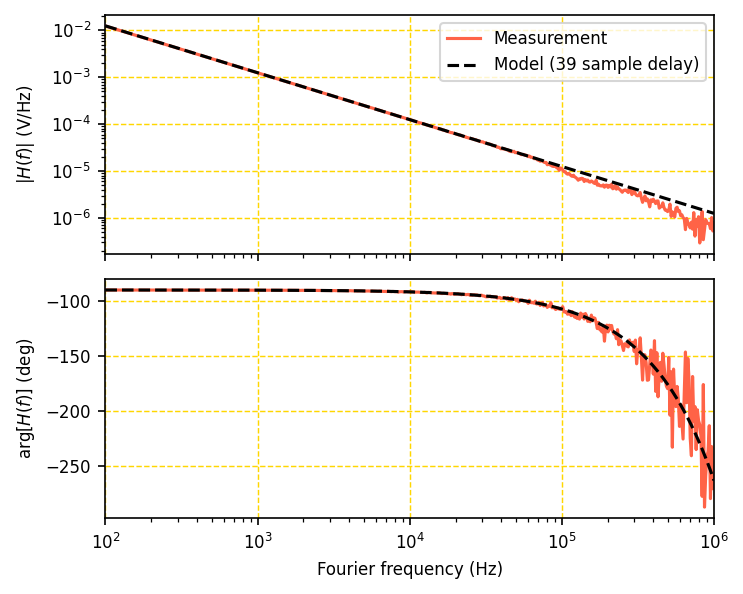

In [6]:
# DSP delay component, 42 clock samples:
delay_samples = int(np.round(x))
print(f"Implementing {delay_samples} sample delay")
c_delay = lc.DSPDelayComponent('Delay', sps, delay_samples)

# LOOP object, mixer*delay:
loop = LOOP(sps, [c_mixer, c_delay])

# Bode plot
fig, ax = plt.subplots(2,1, figsize=(5,4))
ax[0].loglog(frfr, df['mag_V_Hz'], label='Measurement', color='tomato')
ax[1].semilogx(frfr, df['phase_unwrapped'], label='1 Hz/V', color='tomato')
ax[0].loglog(frfr, loop.mag(frfr), ls='--', c='k', label=f'Model ({delay_samples} sample delay)')
ax[1].semilogx(frfr, loop.phase_deg_unwrapped(frfr), ls='--', c='k')
ax[0].set_xticklabels([])
ax[1].set_xlabel('Fourier frequency (Hz)')
ax[0].set_ylabel(r'$|H(f)|~(\rm V/Hz)$')
ax[1].set_ylabel(r'${\rm arg}[H(f)]~({\rm deg})$')
ax[0].set_xlim(np.min(frfr), np.max(frfr))
ax[1].set_xlim(np.min(frfr), np.max(frfr))
ax[0].legend()
plt.tight_layout()
fig.align_ylabels()
plt.show()